In [ ]:
#!pip install ultralytics opencv-python tensorflow
!pip install ultralytics roboflow -q
#!pip install inference-sdk
#!pip install roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="acHOSbLjl8MbNOb0fDuA")
project = rf.workspace("emotions-dectection").project("human-face-emotions")
version = project.version(30)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Human-face-emotions-30 in yolov8:: 100%|██████████| 18812/18812 [00:02<00:00, 6970.08it/s] 


In [ ]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)


Dataset path: /content/Human-face-emotions-30
data.yaml exists: True

Dataset folder content:
- data.yaml
- README.roboflow.txt
- valid
- README.dataset.txt
- train
- test


In [ ]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)
class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))


{'names': ['anger', 'content', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'], 'nc': 8, 'roboflow': {'license': 'CC BY 4.0', 'project': 'human-face-emotions', 'url': 'https://universe.roboflow.com/emotions-dectection/human-face-emotions/dataset/30', 'version': 30, 'workspace': 'emotions-dectection'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Classes: ['anger', 'content', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 8


In [ ]:
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

print (train_img_dir)
print (valid_img_dir)
print (test_img_dir)

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

/content/Human-face-emotions-30/train/images
/content/Human-face-emotions-30/valid/images
/content/Human-face-emotions-30/test/images


,Train Images,Validation Images,Test Images
0,6586,1873,941


In [ ]:
# sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:12]

# for img in sample_images:
#     display(Image(filename=img, width=400))


In [ ]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


In [ ]:
results = model.train(
     data=data_yaml_path,
     epochs=10,
     imgsz=640,
     batch=8,
     name="Face_Expression_yolov8_roboflow"
 )


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Human-face-emotions-30/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Face_Expression_yolov8_roboflow, nbs=64, nms=False, opset=None, optimize=False, optimizer=


 results.png


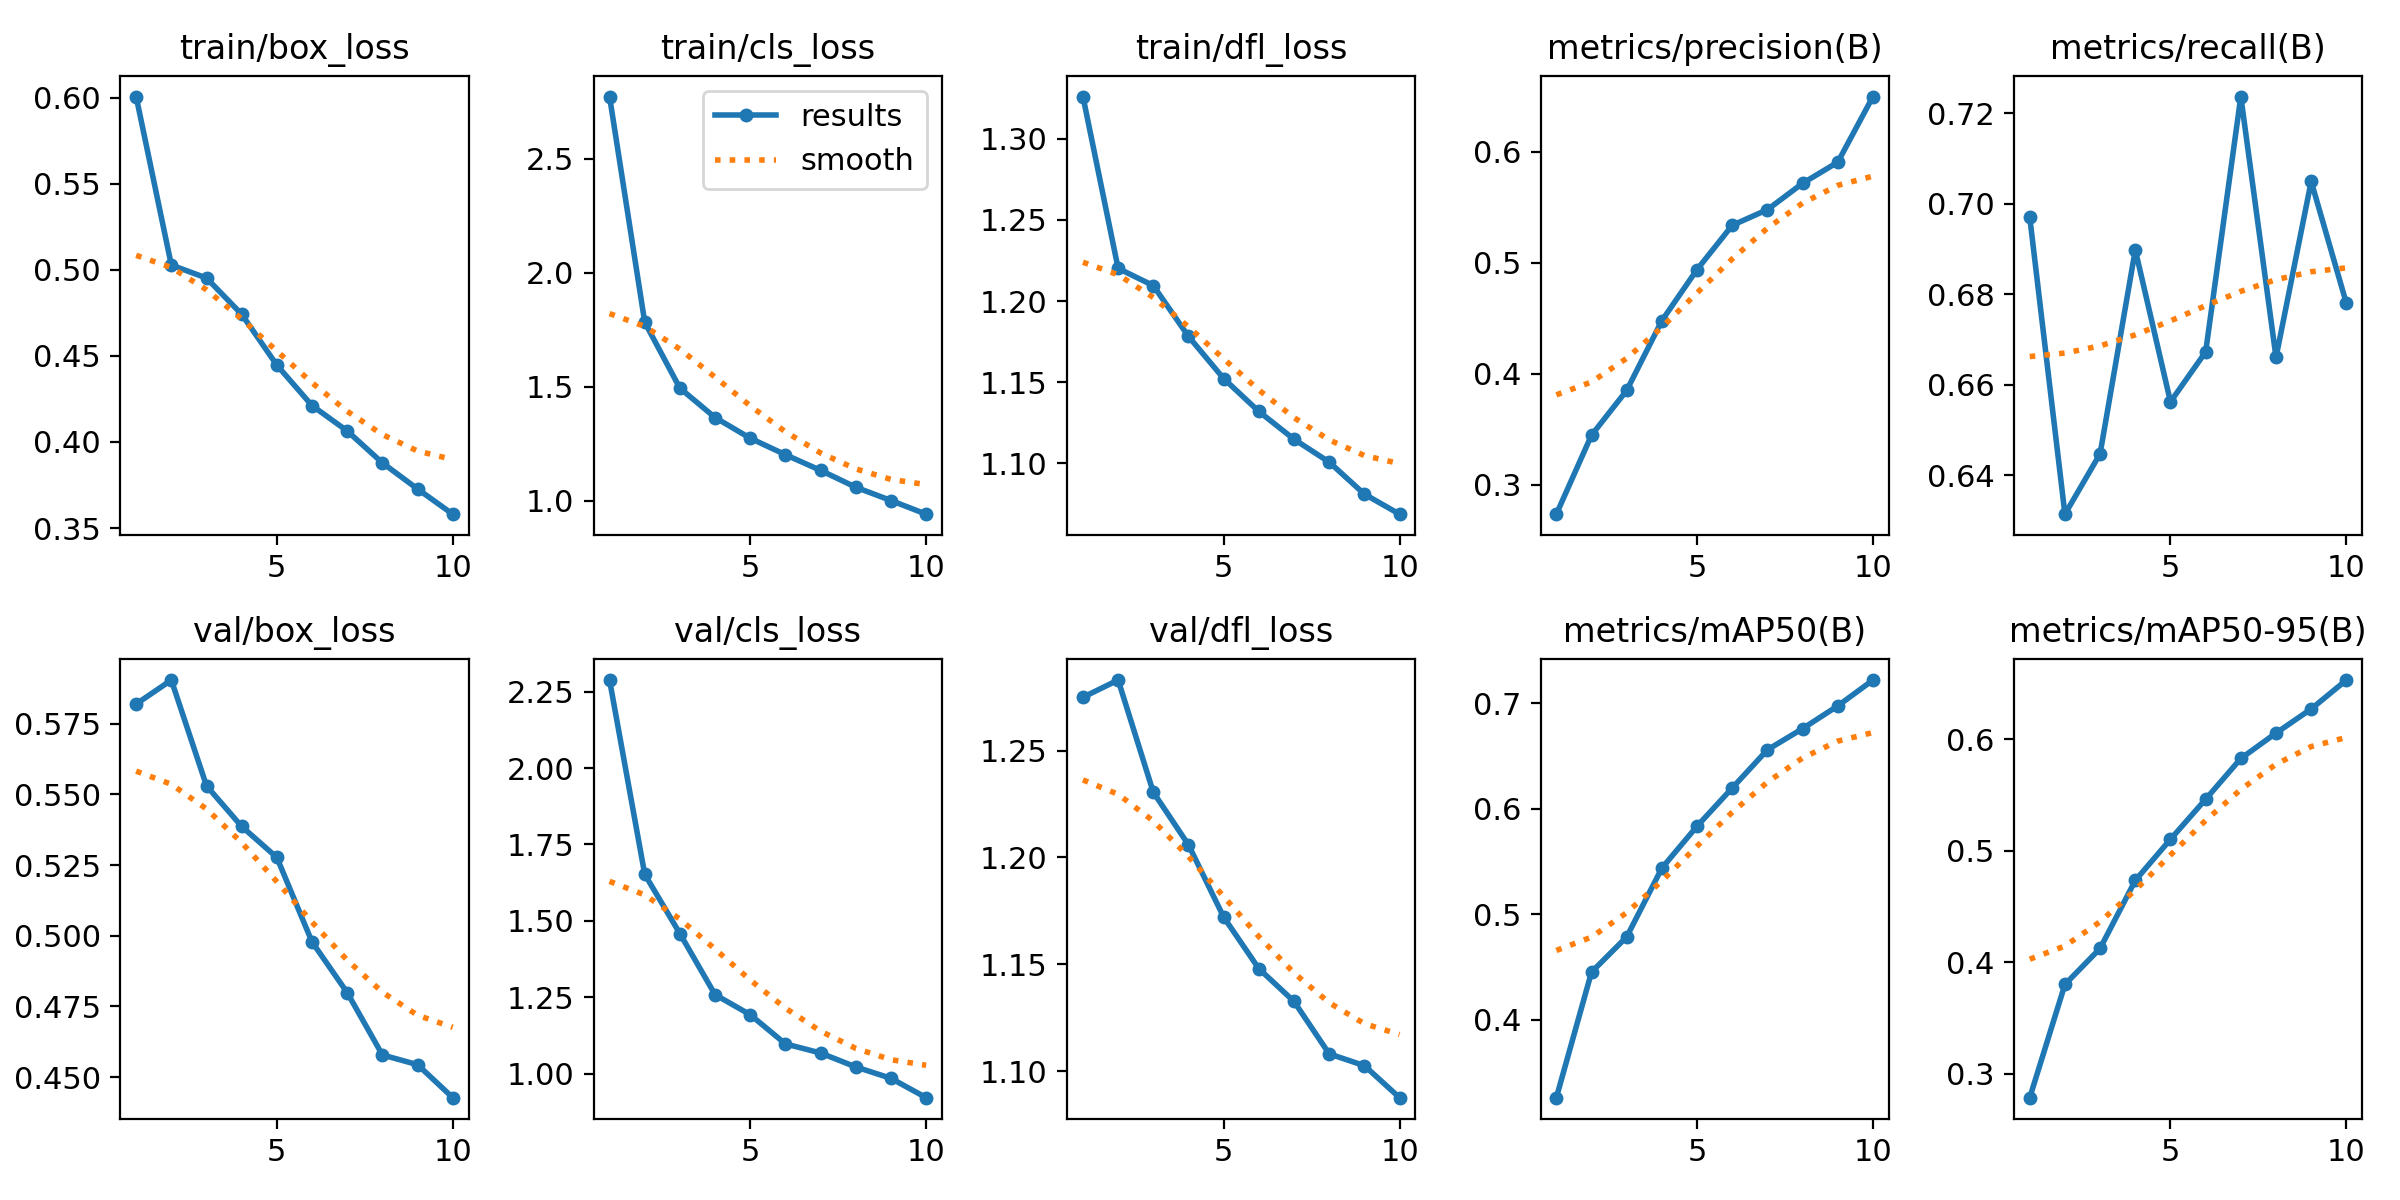


 confusion_matrix.png


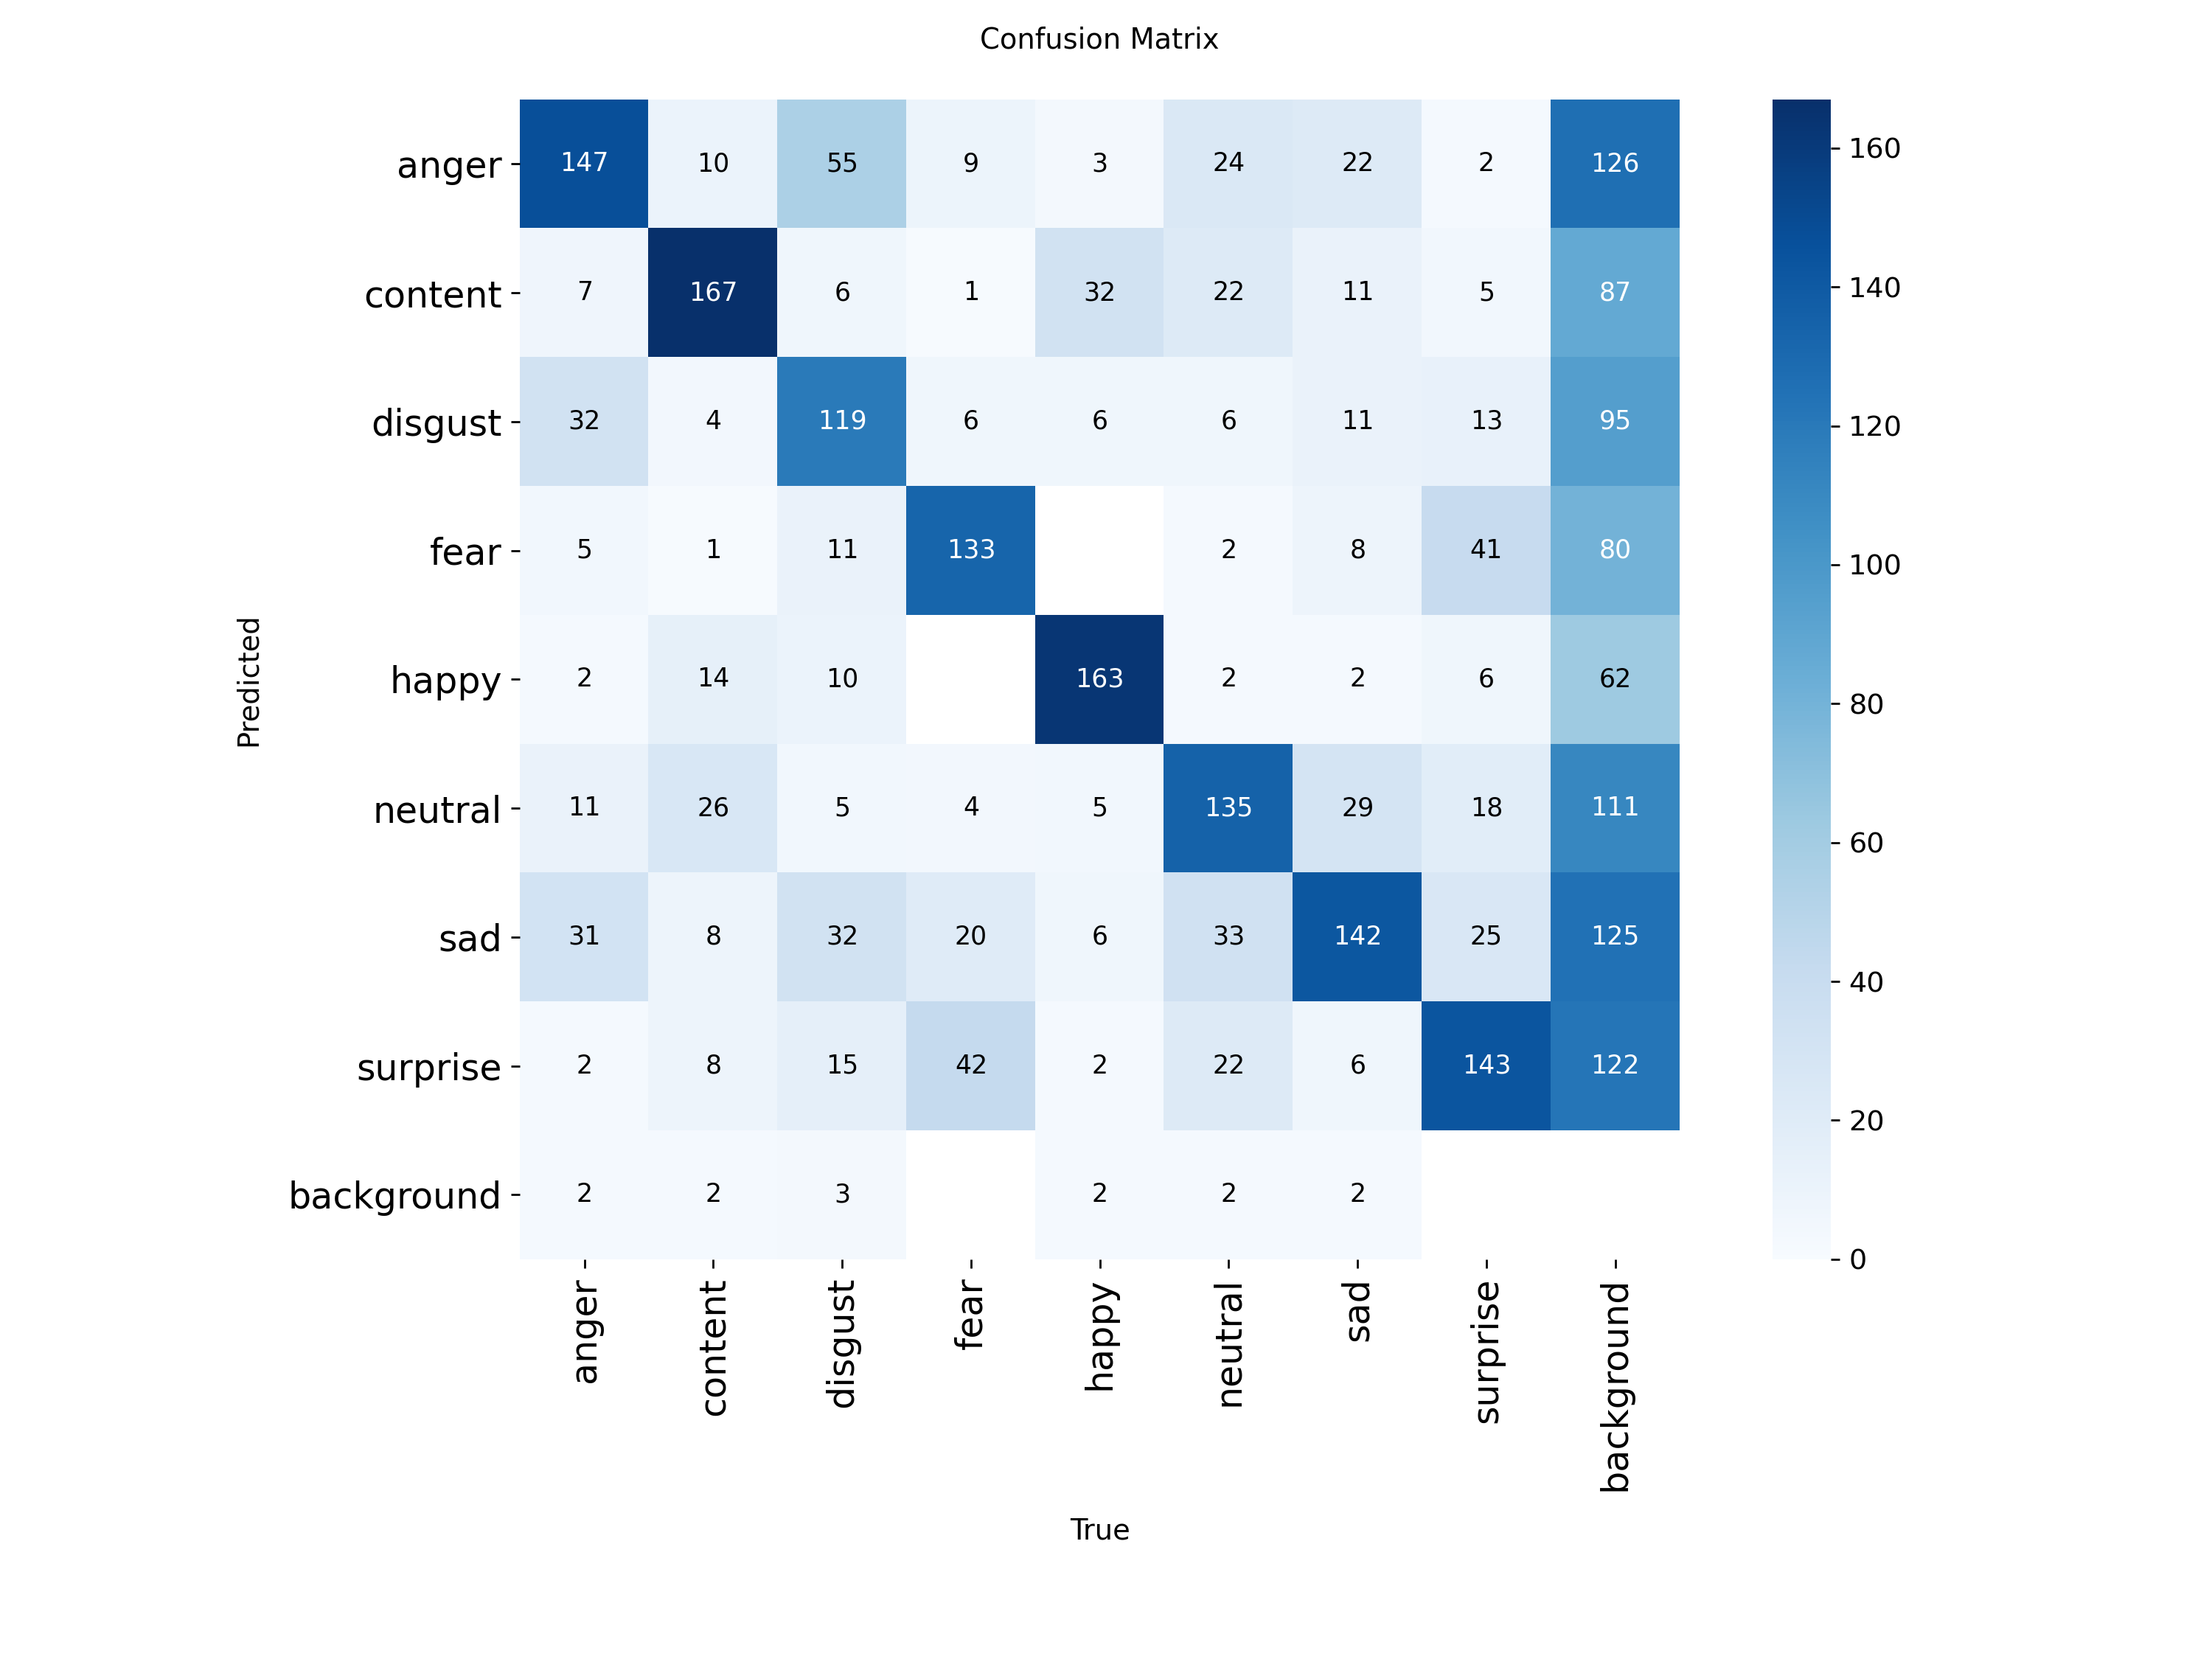


 BoxPR_curve.png


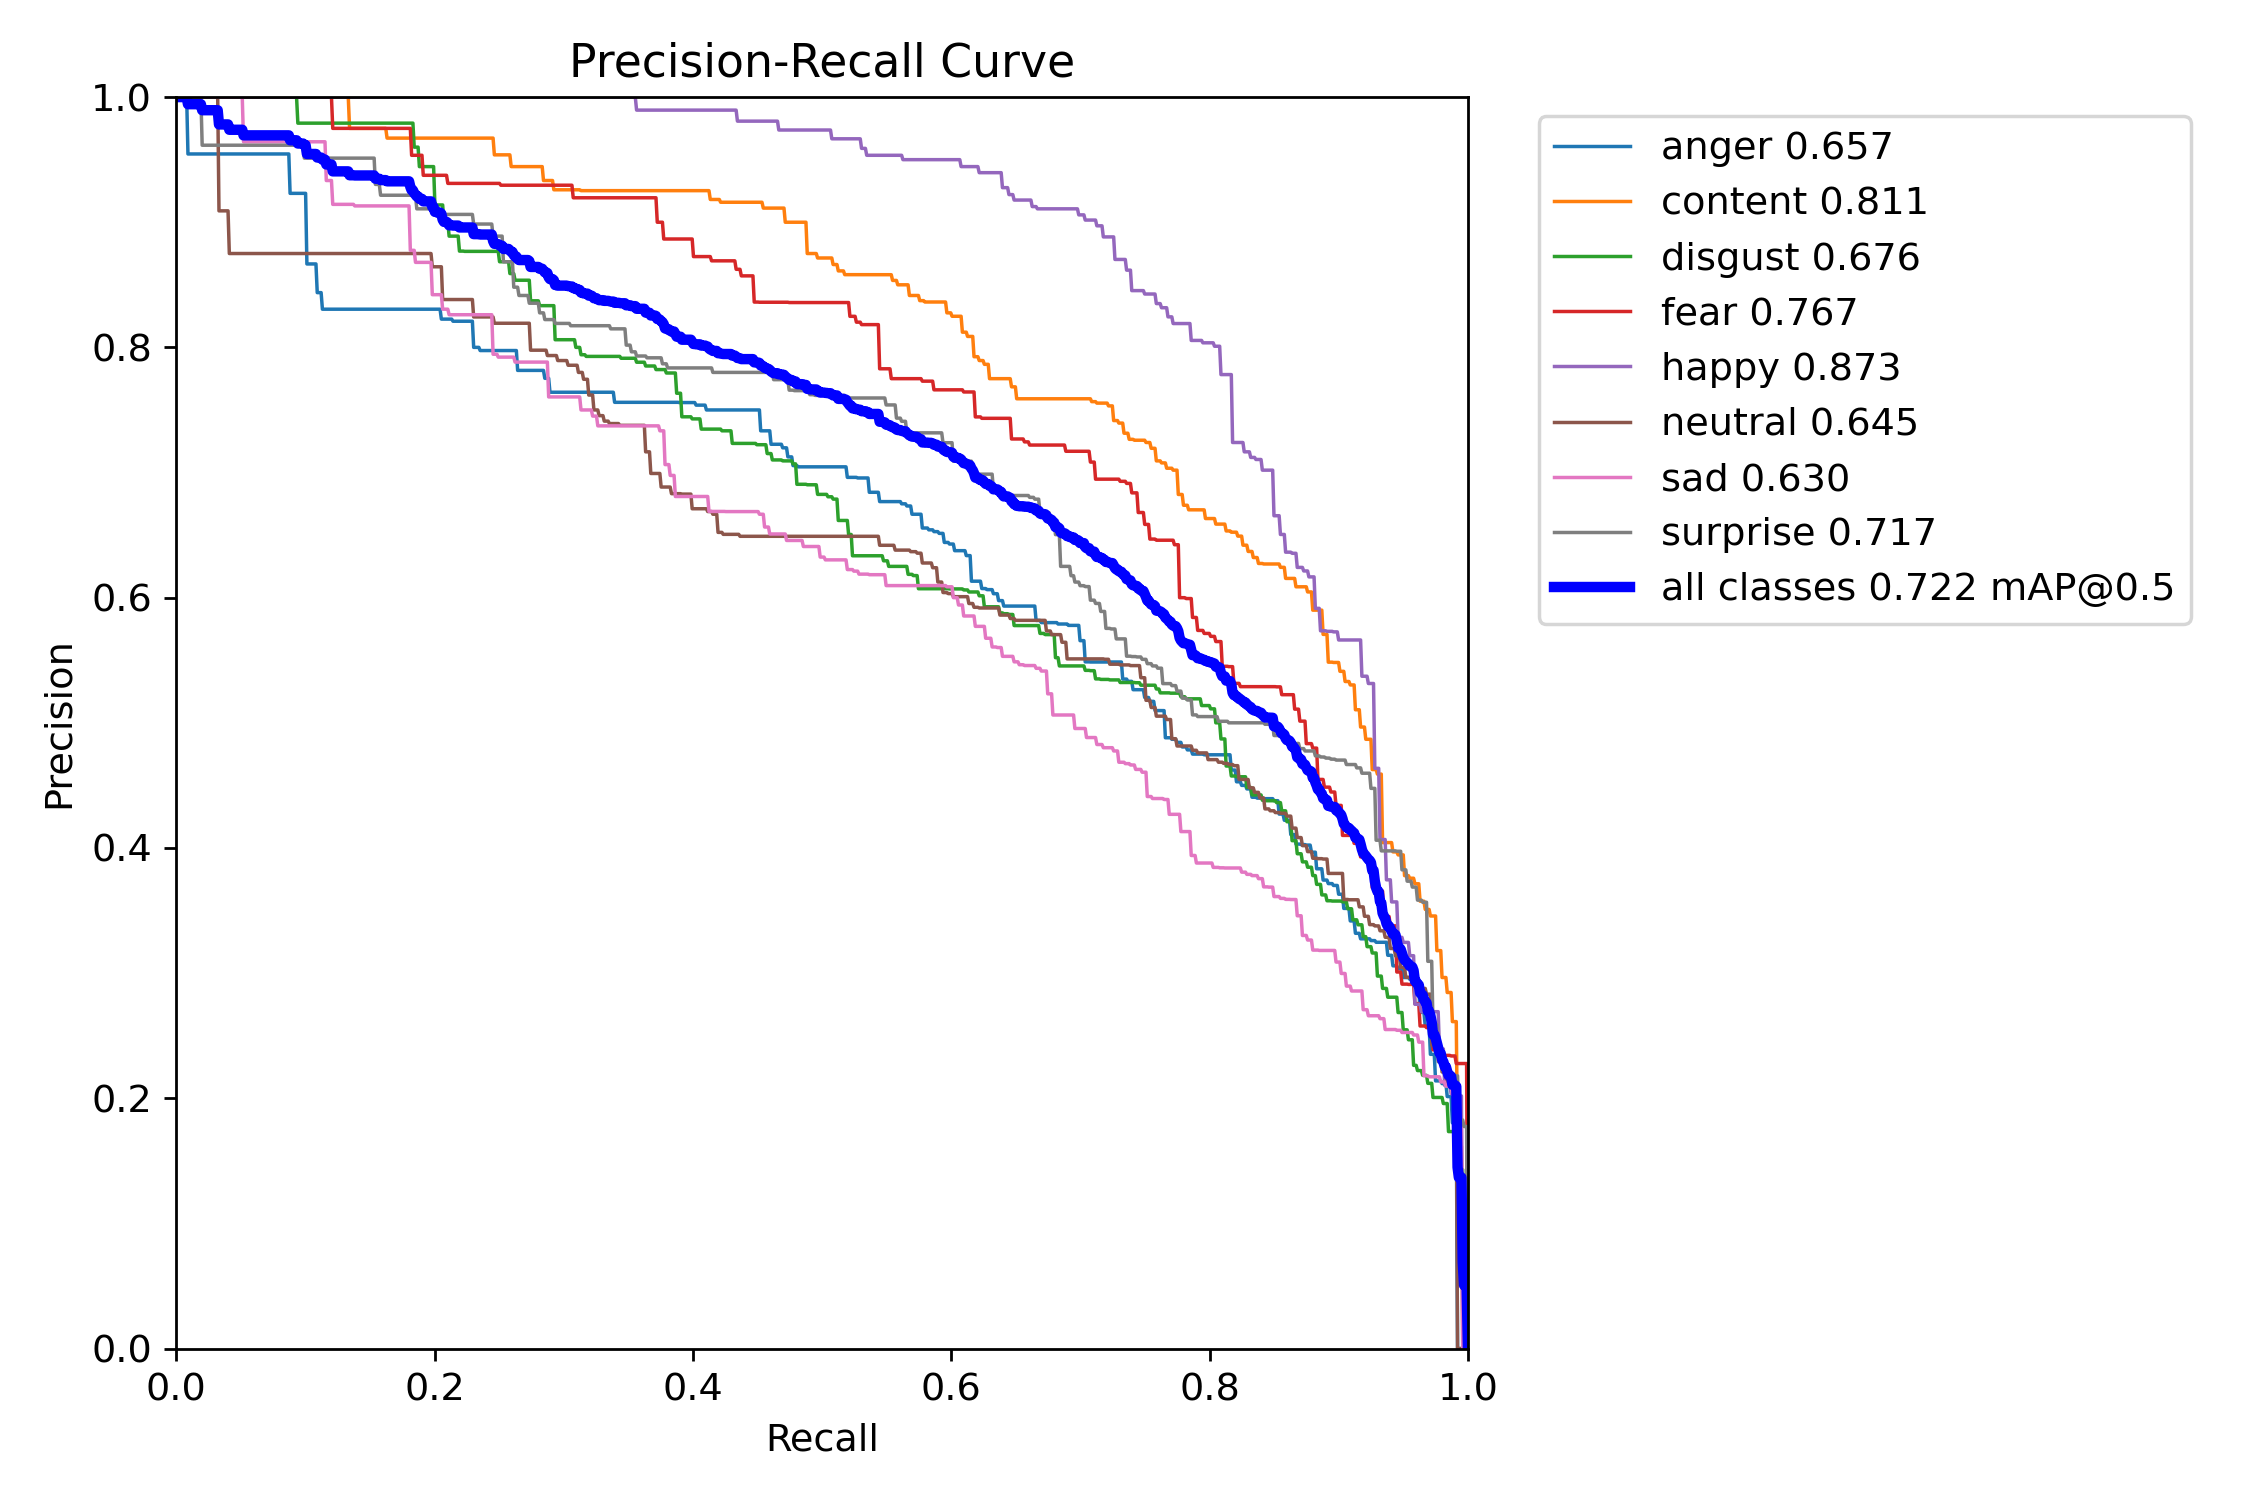


 BoxF1_curve.png


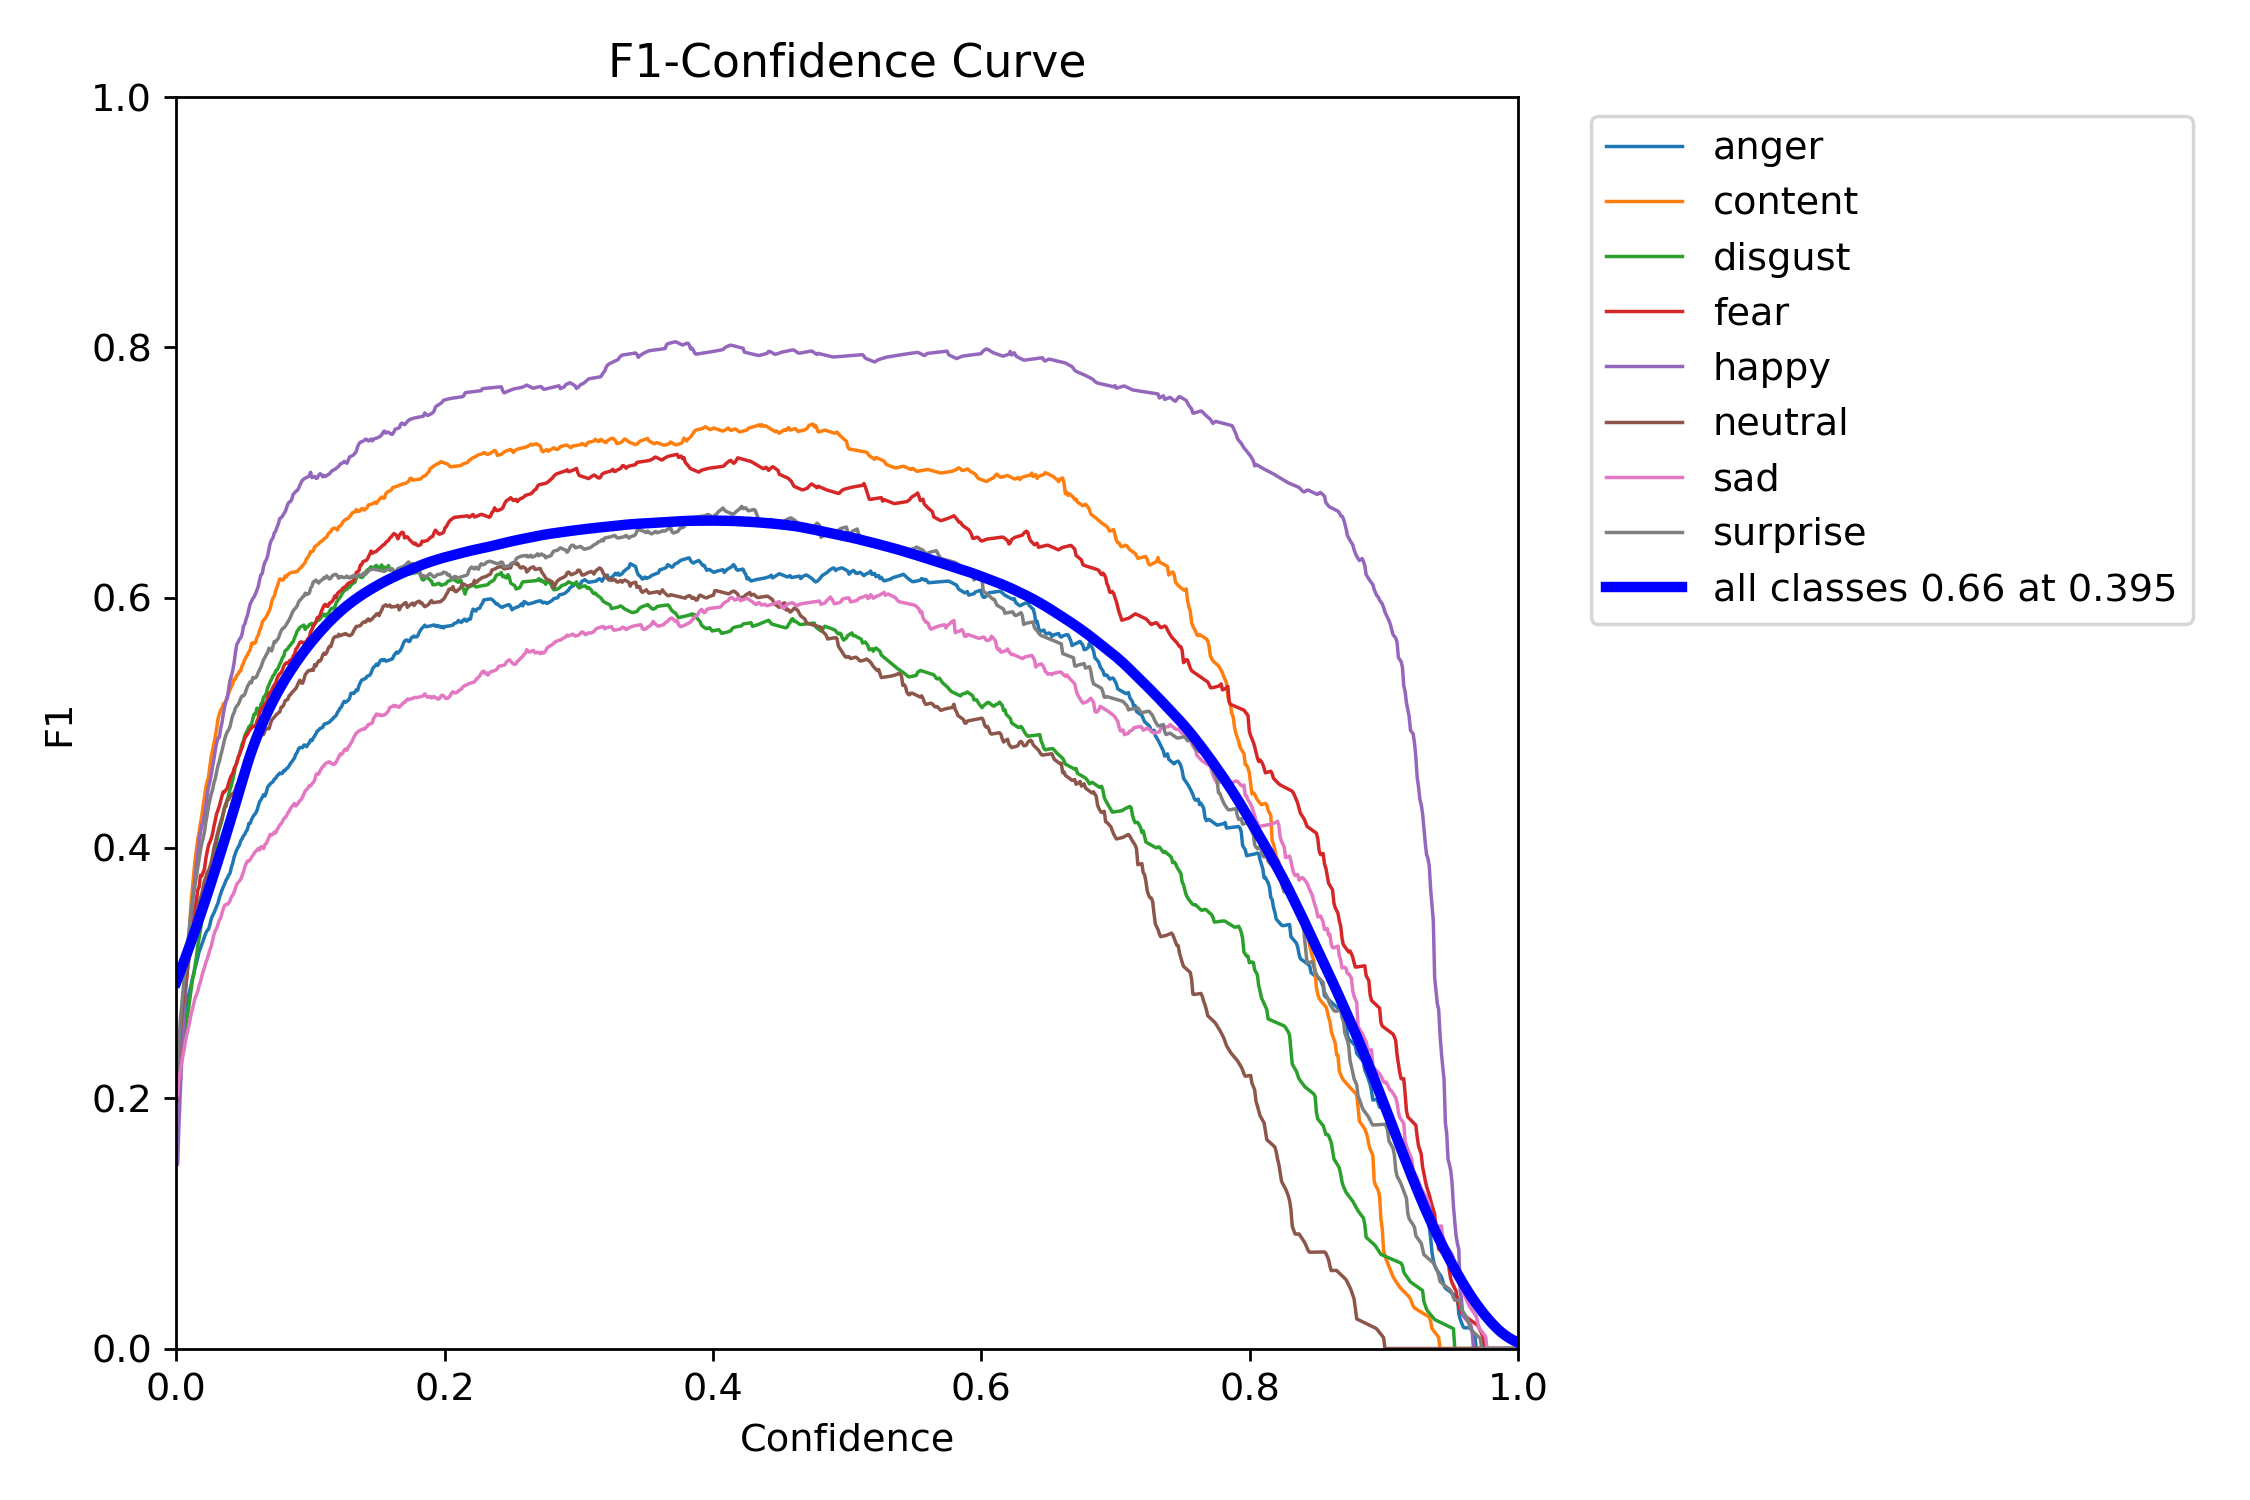


 BoxP_curve.png


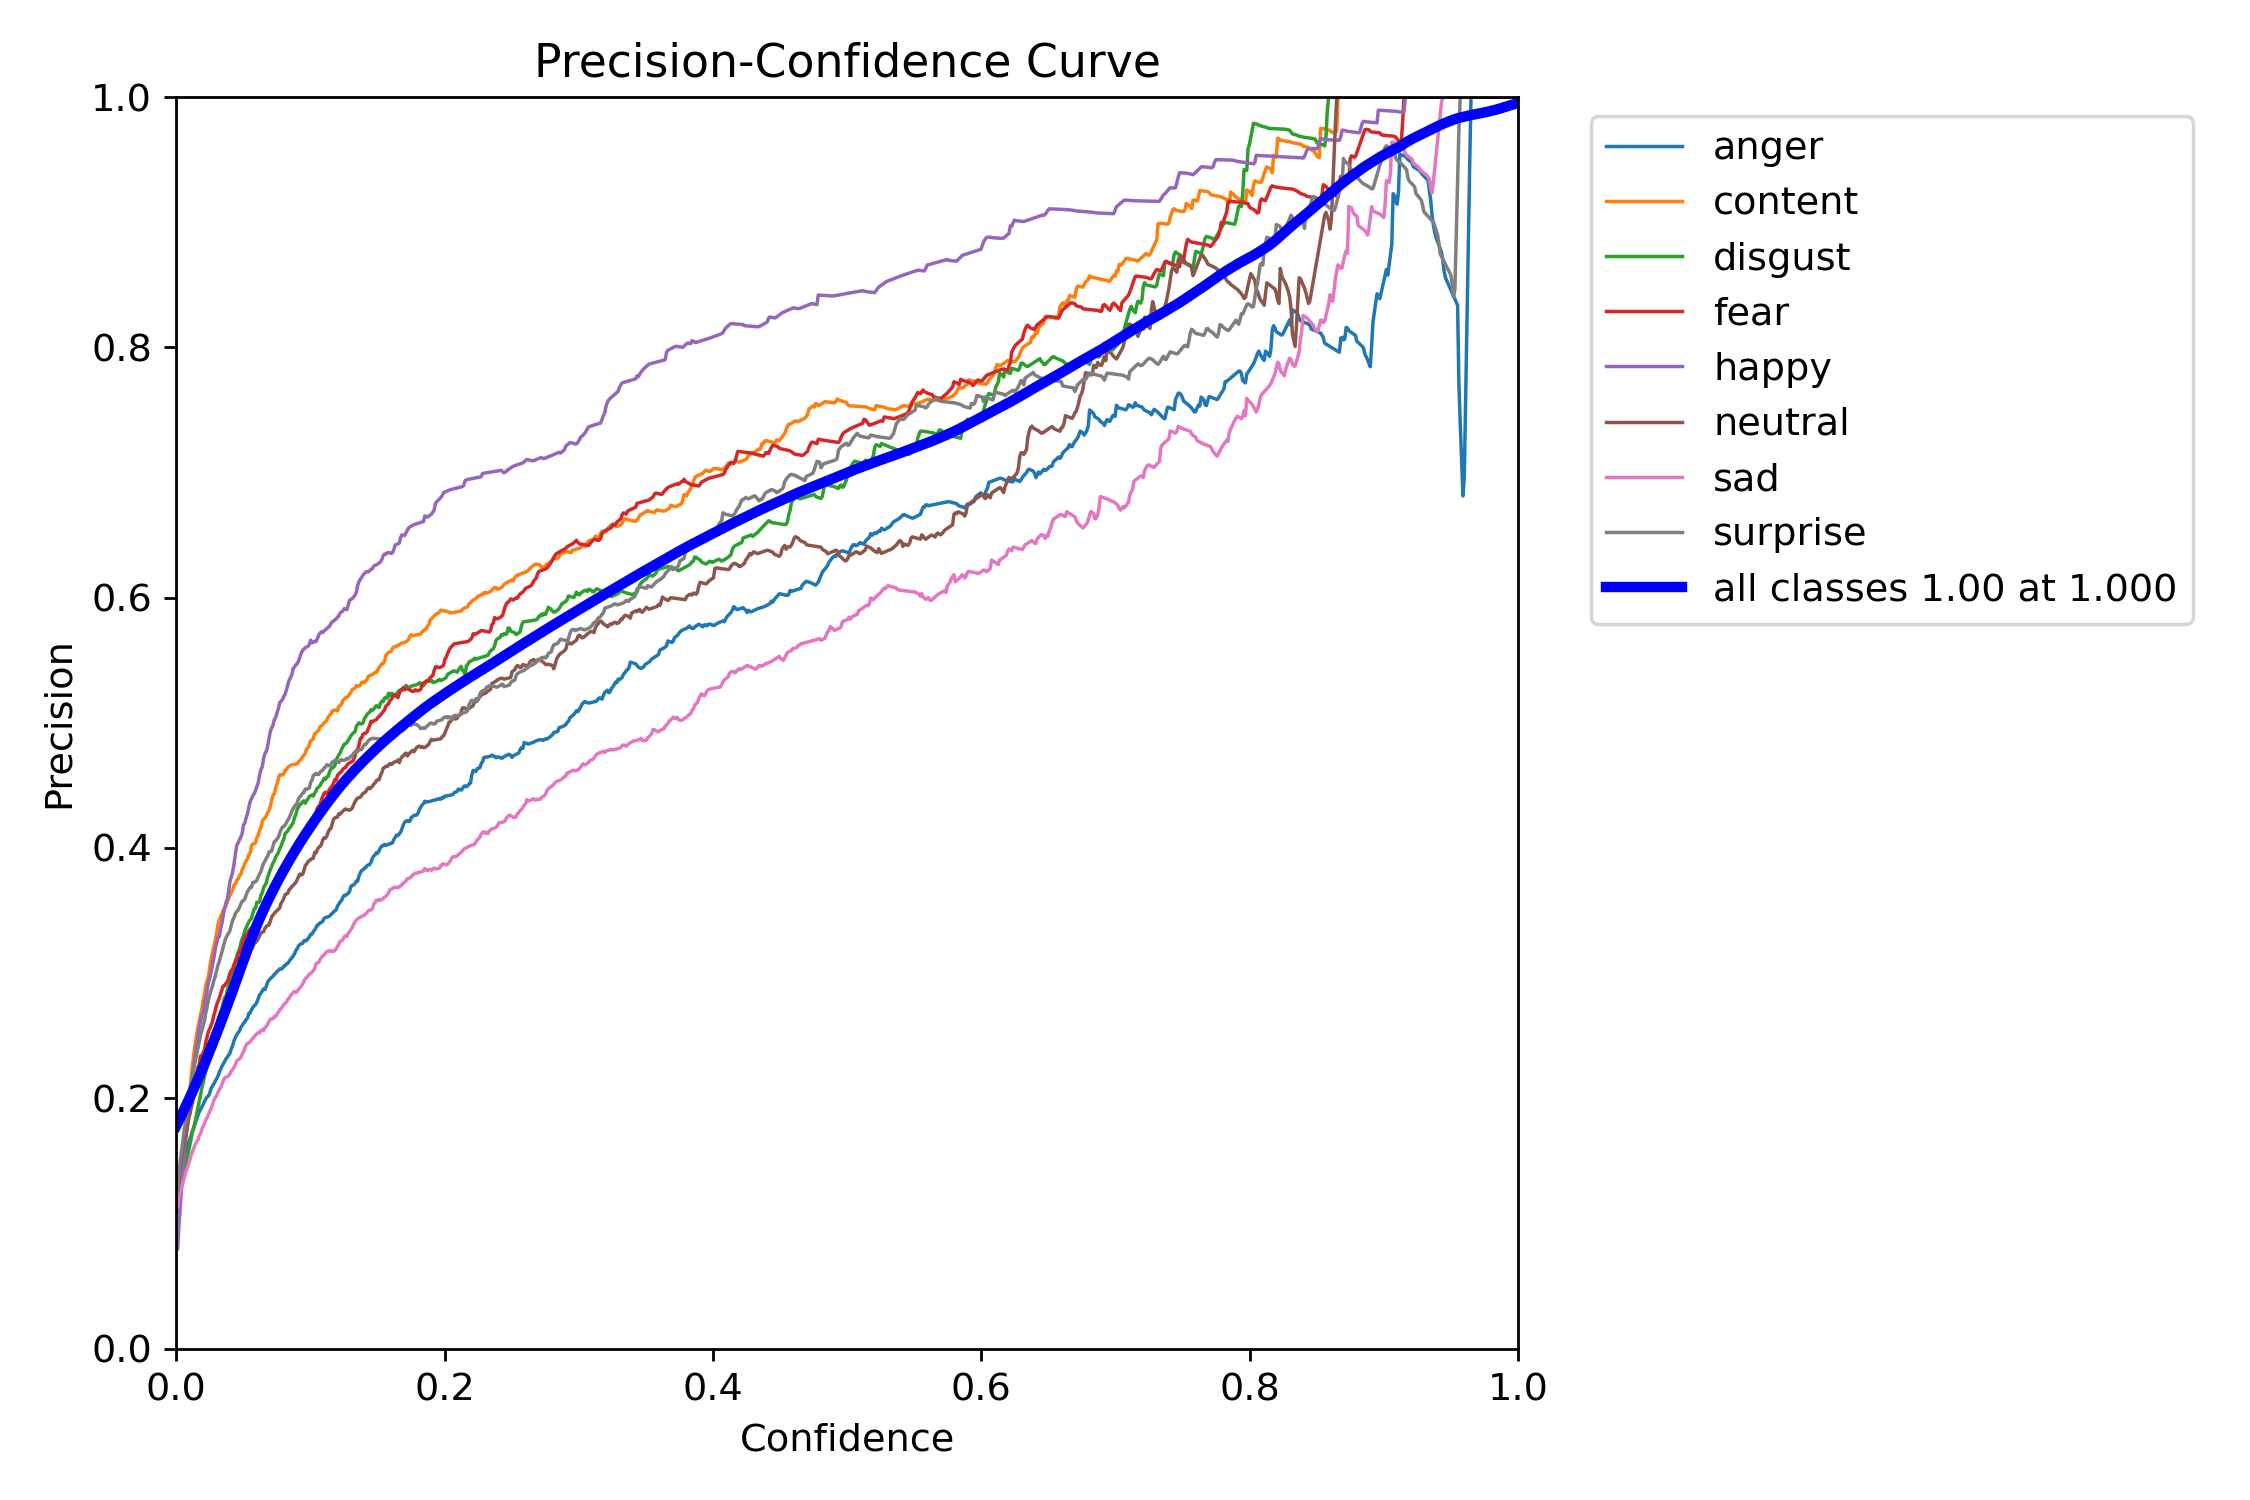


 BoxR_curve.png


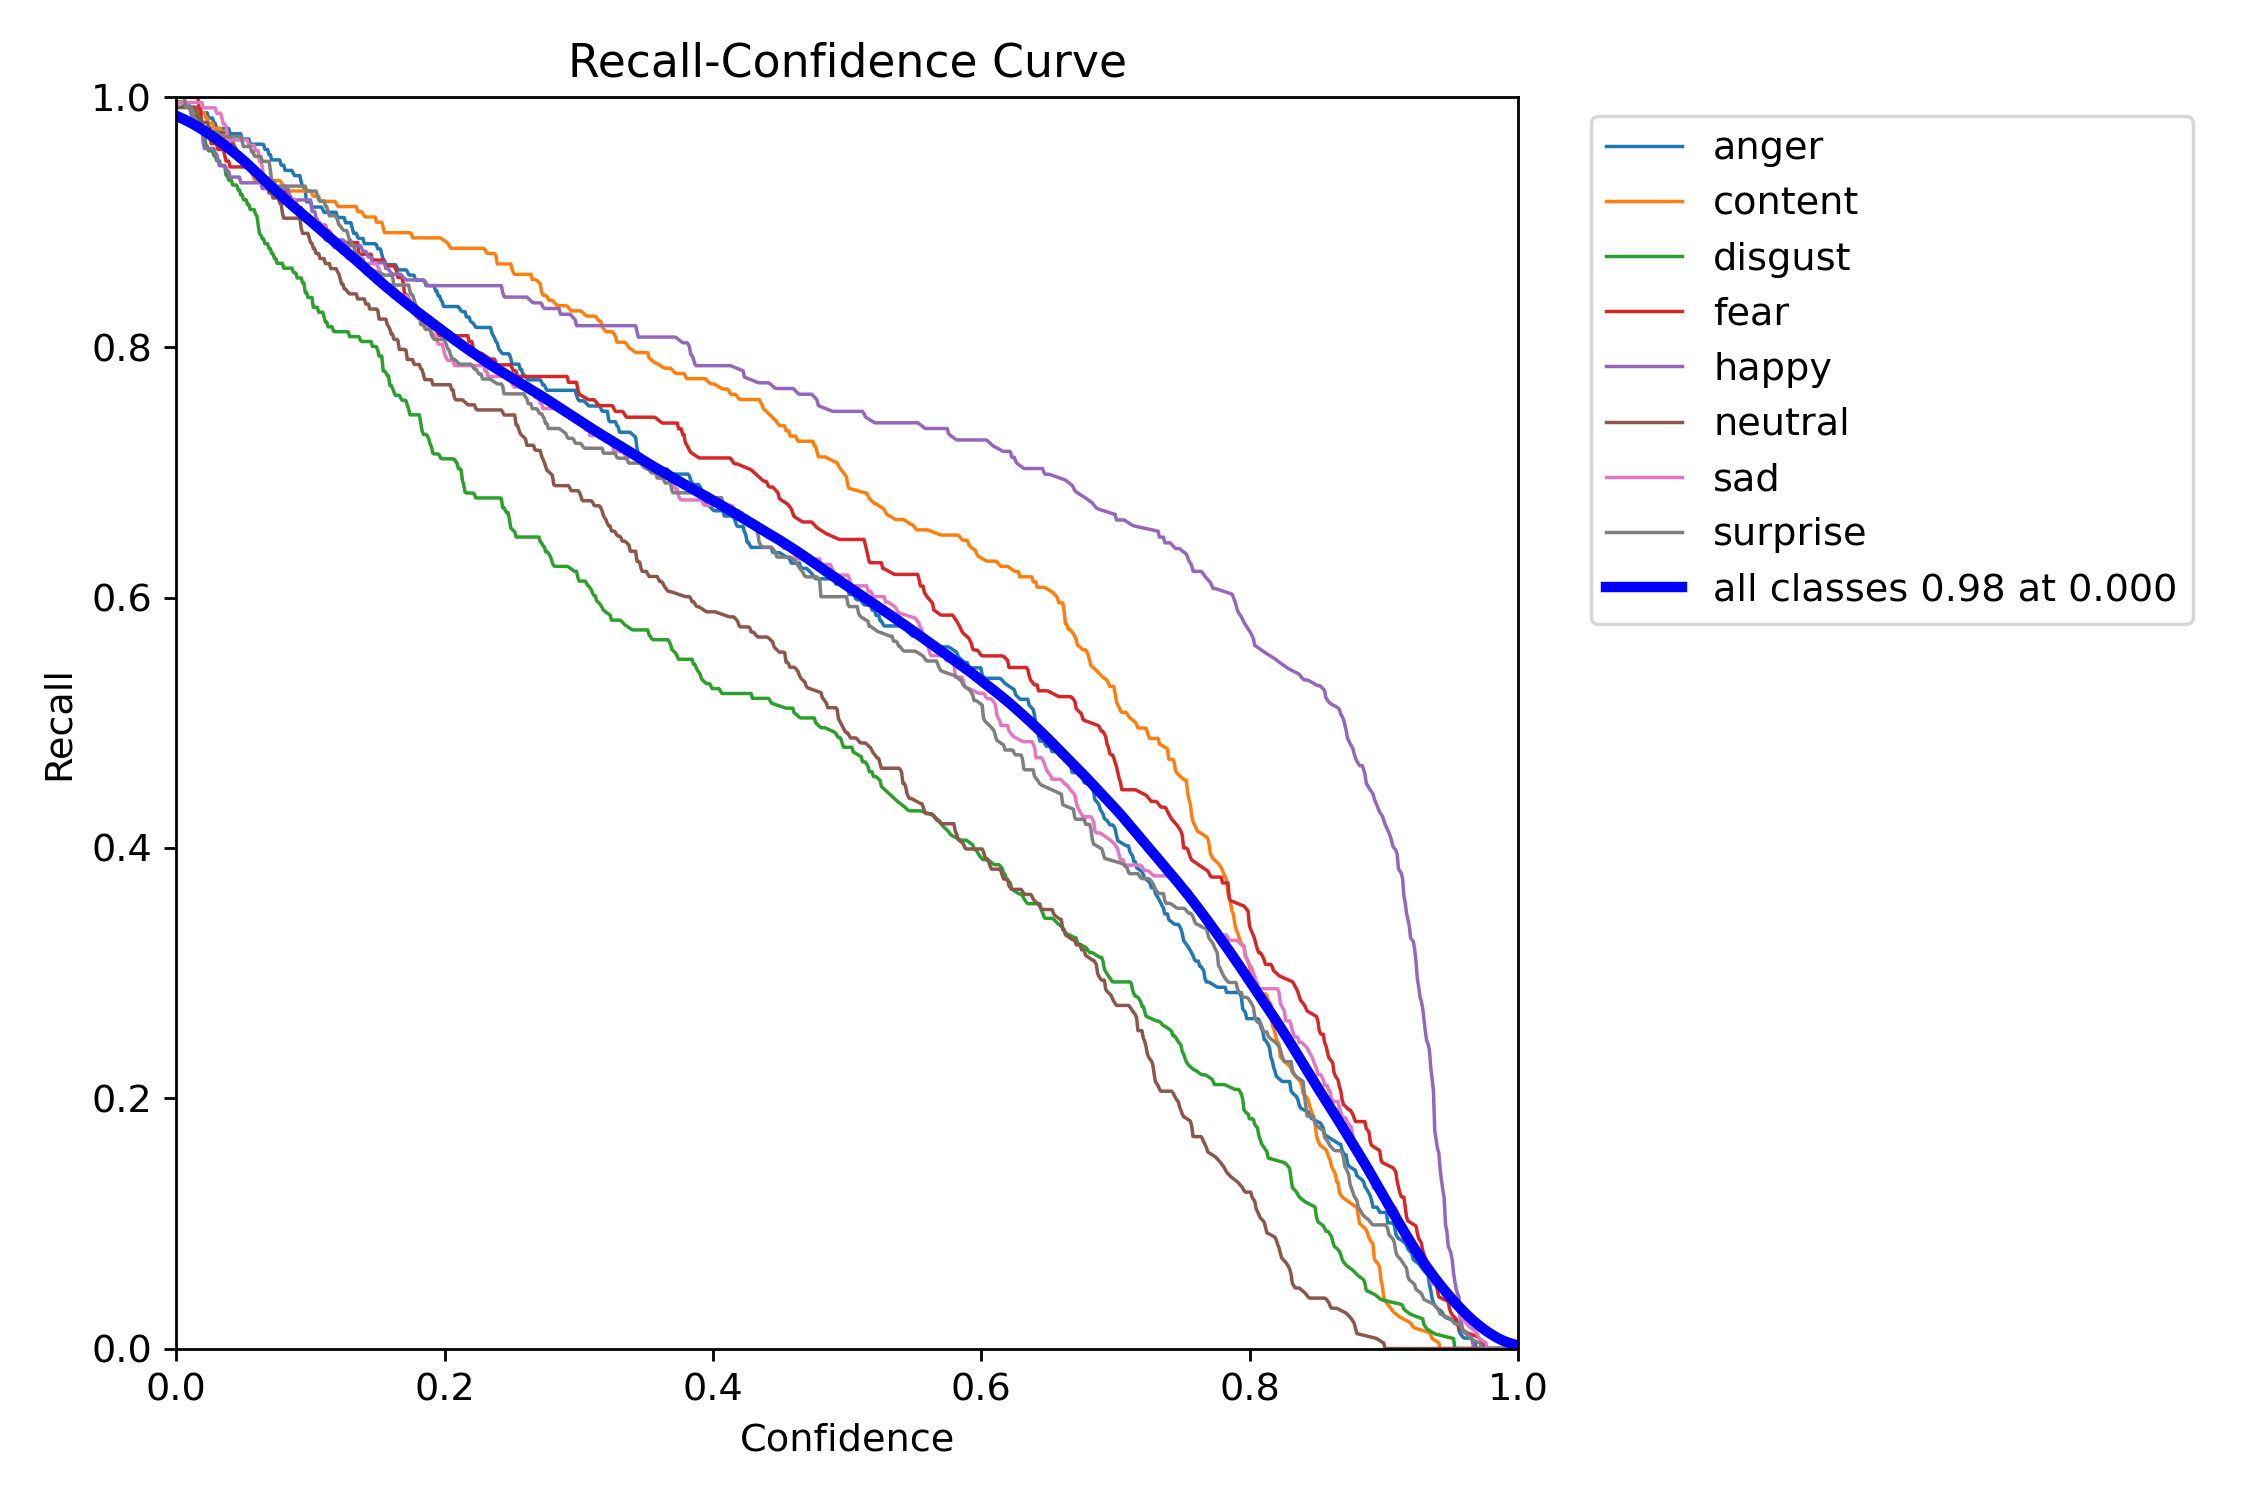

In [ ]:
train_run_dir = "/content/runs/detect/Face_Expression_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)

In [ ]:
#train_run_dir = "/content/runs/detect/Face_Expression_yolov8_roboflow"

best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1684.3±625.0 MB/s, size: 39.5 KB)
val: Scanning /content/Human-face-emotions-30/valid/labels.cache... 1873 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1873/1873 714.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 6.4it/s 18.3s
                   all       1873       1903       0.65      0.678      0.722      0.653
                 anger        235        239       0.58      0.675      0.657      0.556
               content        237        240      0.702      0.774      0.811      0.755
               disgust        254        256      0.628      0.531      0.676      0.614
                  fear        214        215      0.695      0.712      0.767      0.688
                 happy     

In [ ]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.1,
    save=True,
    name="Face_Expression_predictions"
)

print("Prediction completed on test images.")


image 1/941 /content/Human-face-emotions-30/test/images/ffhq_1023_png_jpg.rf.773445fdeb82226802837a6f470c2a27.jpg: 640x640 1 content, 1 happy, 1 surprise, 7.2ms
image 2/941 /content/Human-face-emotions-30/test/images/ffhq_1025_png_jpg.rf.56f7797baa7bd6caa89c3a269cd17afb.jpg: 640x640 1 happy, 7.2ms
image 3/941 /content/Human-face-emotions-30/test/images/ffhq_1043_png_jpg.rf.8681630b812cc7b9c88f469eed896107.jpg: 640x640 1 neutral, 1 surprise, 7.2ms
image 4/941 /content/Human-face-emotions-30/test/images/ffhq_1047_png_jpg.rf.74278e14f25c90187060b939fc1bda1c.jpg: 640x640 1 neutral, 7.2ms
image 5/941 /content/Human-face-emotions-30/test/images/ffhq_1059_png_jpg.rf.d002e05edfa8b4eba78e1198feacb16f.jpg: 640x640 1 neutral, 7.2ms
image 6/941 /content/Human-face-emotions-30/test/images/ffhq_1063_png_jpg.rf.3c2b0d0532c17d89ffe043c65e03ebfc.jpg: 640x640 1 content, 7.2ms
image 7/941 /content/Human-face-emotions-30/test/images/ffhq_1070_png_jpg.rf.4c31d4515a2d8ad47d1a4fb2aff162de.jpg: 640x640 1 neu

Saving Smile_girl.jpg to Smile_girl.jpg
Uploaded image path: /content/Smile_girl.jpg

image 1/1 /content/Smile_girl.jpg: 448x640 1 happy, 42.9ms
Speed: 2.7ms preprocess, 42.9ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/Face_recognition
Prediction completed on uploaded image.


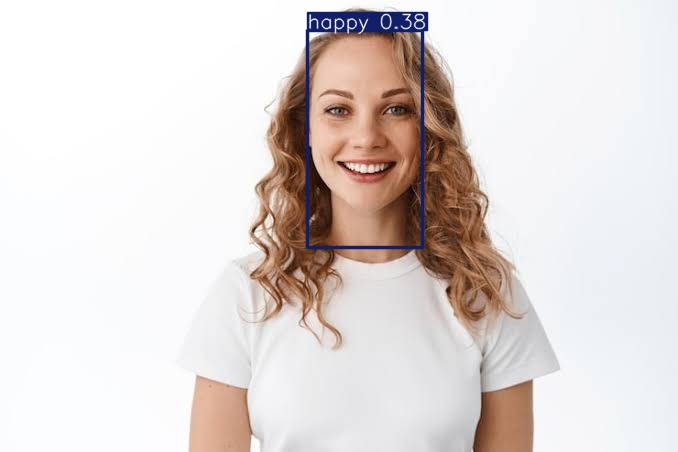

,Detected Object,Confidence Score
0,happy,0.379


In [ ]:
from google.colab import files
from IPython.display import Image, display
import os
import glob

uploaded = files.upload()

# get the uploaded filename
uploaded_image = list(uploaded.keys())[0]
image_path = os.path.join("/content", uploaded_image)

print("Uploaded image path:", image_path)

single_result = best_model.predict(
    source=image_path,
    conf=0.05,
    save=True,
    exist_ok=True,
    name="Face_recognition"
)

print("Prediction completed on uploaded image.")

uploaded_prediction_dir = "/content/runs/detect/Face_recognition"
imgs = [f for f in glob.glob(os.path.join(uploaded_prediction_dir, "*"))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))]

latest_img = max(imgs, key=os.path.getmtime)
display(Image(filename=latest_img, width=700))

detections = []

best_box = None
best_conf = -1

for result in single_result:
    names = result.names

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        if conf > best_conf:
            best_conf = conf
            best_box = {
                "Detected Object": label,
                "Confidence Score": round(conf, 3)
            }

if best_box is None:
    print("No object detected.")
else:
    detections.append(best_box)
    display(pd.DataFrame(detections))

In [ ]:

# # test_img_dir = os.path.join(dataset_path, "test", "images")

# uploaded = files.upload()
# uploaded_image = list(uploaded.keys())[0]

#  test_results = best_model.predict(
#     #  source=test_img_dir,
#      source=uploaded_image
#      conf=0.1,
#      save=True,
#      imgsz=1280,      # Match your training size
#      verbose=False,
#      name="Expression_predictions"
#  )

#  print ("Prediction completed.")

In [ ]:
#  import glob
#  import os
#  from ultralytics import YOLO
#  import pandas as pd
#  from IPython.display import display

#  # 1. CORRECT dataset path - images are in /content directly
#  dataset_path = "/content/runs/detect/Face_Expression_yolov8_roboflow"

#  # 2. Find all images
#  image_paths = glob.glob(os.path.join(dataset_path, "*.jpg")) + \
#                glob.glob(os.path.join(dataset_path, "*.jpeg"))

#  print(f"Dataset path: {dataset_path}")
#  print(f"Found {len(image_paths)} images:")
#  for img in image_paths:
#      print(f"  - {img}")

#  # 3. Load your model
#  model = YOLO("/content/runs/detect/Face_Expression_yolov8_roboflow/weights/best.pt")

#  # 4. Run prediction on all images
#  if len(image_paths) > 0:
#      results = model.predict(image_paths, conf=0.05, save=True, verbose=True)
#      print("\nPrediction completed!")

#      # 5. Process detections
#      all_detections = []
#      for img_path, result in zip(image_paths, results):
#          for box in result.boxes:
#              cls_id = int(box.cls[0])
#              conf = float(box.conf[0])
#              label = result.names[cls_id]
#              all_detections.append({
#                  "Image": img_path.split('/')[-1],
#                  "Object": label,
#                  "Confidence": round(conf, 3)
#              })

#      if len(all_detections) == 0:
#          print("No objects detected.")
#      else:
#          display(pd.DataFrame(all_detections))
#  else:
#      print("No images found!")

In [ ]:
#  from ultralytics import YOLO

#  # Use pre-trained model that detects people/faces
#  model = YOLO("yolov8n.pt")  # Pre-trained on COCO dataset

#  # Run prediction
#  results = model.predict(image_paths, conf=0.1, save=True, verbose=True)

#  # View detections
#  for img_path, result in zip(image_paths, results):
#      print(f"\n{img_path}:")
#      if len(result.boxes) > 0:
#          for box in result.boxes:
#              cls_id = int(box.cls[0])
#              conf = float(box.conf[0])
#              label = result.names[cls_id]
#              print(f"  - {label}: {conf:.3f}")
#      else:
#          print("  No detections")

In [ ]:
# uploaded_prediction_dir = "/content/runs/detect/predict"
# uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

# for img in uploaded_pred_images[:10]:
#     display(Image(filename=img, width=600))


In [ ]:
#  import glob, os

#  uploaded_prediction_dir = "/content/runs/detect/Expression_predictions"
#  uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

#  print("Found", len(uploaded_pred_images), "prediction images")


In [ ]:
#  import cv2
#  from PIL import Image
#  import matplotlib.pyplot as plt

#  for img_path in uploaded_pred_images:
#      img = cv2.imread(img_path)
#      # Adjust this depending on how your filenames are structured
#      label = os.path.basename(img_path).split('_')[0]
#      cv2.putText(img, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
#                  1, (0, 255, 0), 2, cv2.LINE_AA)
#      plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#      plt.axis('off')
#      plt.show()


In [ ]:
#  import numpy as np

#  # Example: pretend your model predicted probabilities for 4 emotions
#  model_output = np.array([0.1, 0.7, 0.1, 0.1])  # highest is index 1

#  print("model_output:", model_output)

In [ ]:
#   import numpy as np
#   from PIL import Image
#   import requests
#   from io import BytesIO

#  # # Your emotion mapping
#   emotion_map = {0: "angry", 1: "happy", 2: "sad", 3: "surprised"}

#  # # Simulated model output (replace with your actual model_output)
#   model_output = np.array([0.1, 0.8, 0.05, 0.05])  # example - happy has highest score

#  # # Get predicted class and emotion name
#   predicted_class = model_output.argmax()   # gives 1
#   emotion_name = emotion_map[predicted_class]

#   print("Predicted class:", predicted_class)
#   print("Predicted emotion:", emotion_name)


In [ ]:
# from IPython.display import Image, display

# uploaded_prediction_dir = "/content/runs/detect/Expression_prediction"
# uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

# for img in uploaded_pred_images:
#     display(Image(filename=img, width=700))

In [ ]:
# detections = []
# CONF_THRESHOLD = 0.05  # Adjust based on your needs

# for result in single_result:
#      names = result.names

#      for box in result.boxes:
#          cls_id = int(box.cls[0])
#          conf = float(box.conf[0])
#          label = names[cls_id]

#          # Only add if confidence meets threshold
#          if conf >= CONF_THRESHOLD:
#              detections.append({
#                  "Detected Object": label,
#                  "Confidence Score": round(conf, 3)
#              })

# if len(detections) == 0:
#      print("No object detected.")
# else:
#      display(pd.DataFrame(detections))

In [ ]:
# # STEP 1: Run prediction with LOW confidence in model.predict()
# single_result = best_model. (
#     source="/content/runs/detect/Expression_prediction",  # Make sure this path is correct!
#     conf=0.01,                # 🔥 LOW to 0.01 for testing
#     imgsz=1280,               # 🔥 Increase for small faces
#     verbose=False
# )

# # STEP 2: Debug - Check what's detected
# print(f"Number of results: {len(single_result)}")
# print(f"Boxes found: {len(single_result[0].boxes)}")
# print(f"Model classes: {single_result[0].names}")

# if len(single_result[0].boxes) == 0:
#     print("❌ NO BOXES DETECTED - Your model found nothing!")
#     print("Try: Lower conf to 0.01, increase imgsz to 1280")

# # STEP 3: Your detection parsing (now it should work)
# detections = []
# CONF_THRESHOLD = 0.05

# for result in single_result:
#     names = result.names

#     for box in result.boxes:
#         cls_id = int(box.cls[0])
#         conf = float(box.conf[0])
#         label = names[cls_id]

#         # Only add if confidence meets threshold
#         if conf >= CONF_THRESHOLD:
#             detections.append({
#                 "Detected Object": label,
#                 "Confidence Score": round(conf, 3)
#             })

# if len(detections) == 0:
#     print("No object detected.")
# else:
#     print(f"✅ Found {len(detections)} detections!")
#     display(pd.DataFrame(detections))

In [ ]:
import platform
print(platform.python_version())

3.12.13
